## Introdução à Visualização de Dados em R
Neste notebook, exploraremos as principais ferramentas de visualização de dados em R:
as funções gráficas base e a biblioteca `ggplot2`.
A visualização é fundamental para entender padrões, tendências e anomalias em seus dados biológicos.

## 1. Funções de Plotagem Base do R (`plot()`)
O R possui um sistema de gráficos base poderoso e flexível, ideal para visualizações rápidas e personalizadas.
Vamos usar um conjunto de dados biológicos simulados para demonstrar.

In [17]:
# Criando dados simulados de expressão gênica e tamanho de organismo

set.seed(123) # Para reprodutibilidade
organism_size <- rnorm(50, mean = 10, sd = 2) # Tamanho em cm
gene_expression <- 0.5 * organism_size + rnorm(50, mean = 0, sd = 1) + 5 # Expressão gênica

In [18]:
print("Valores de organism_size")
summary(organism_size)
print("Valores de gene_expression")
summary(gene_expression)

[1] "Valores de organism_size"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  6.067   8.881   9.855  10.069  11.396  14.338 

[1] "Valores de gene_expression"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  7.473   9.149  10.195  10.181  11.103  13.232 

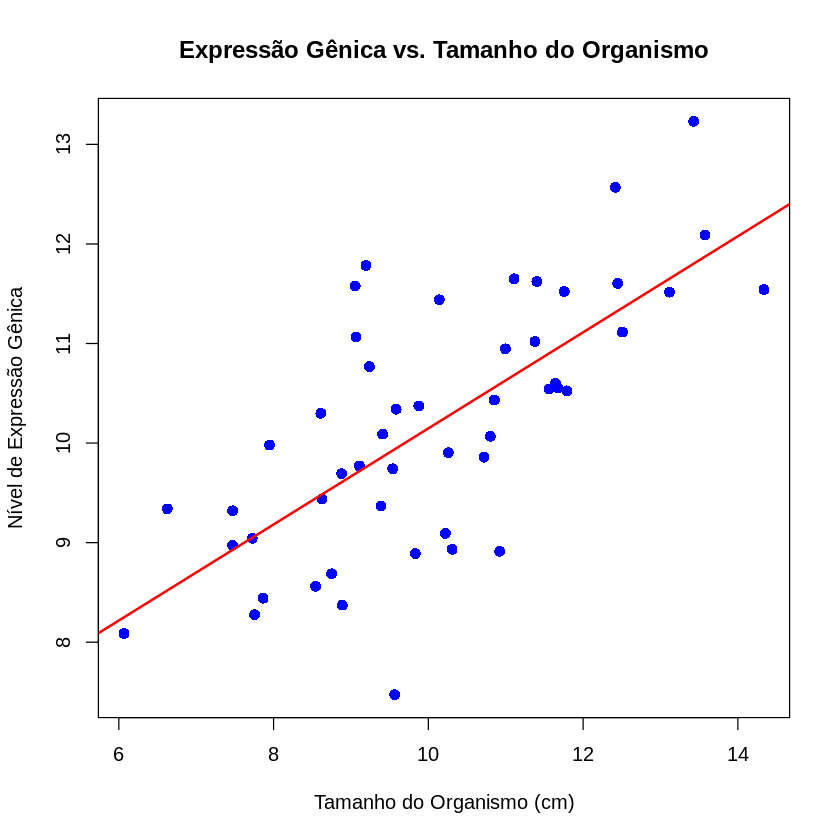

In [19]:
# Plot simples de dispersão
plot(
  x = organism_size,
  y = gene_expression,
  main = "Expressão Gênica vs. Tamanho do Organismo",
  xlab = "Tamanho do Organismo (cm)",
  ylab = "Nível de Expressão Gênica",
  col = "blue", # Cor dos pontos
  pch = 16,     # Tipo de ponto (círculo preenchido)
  cex = 1.2     # Tamanho dos pontos
)

# Adicionando uma linha de regressão (opcional)
abline(lm(gene_expression ~ organism_size), col = "red", lwd = 2)

## 2. A Biblioteca `ggplot2`
`ggplot2` é uma das bibliotecas mais populares e poderosas para criação de gráficos em R,
baseada na "Grammar of Graphics". Ela permite construir gráficos complexos e esteticamente agradáveis
de forma modular.

Primeiro, precisamos instalar e carregar a biblioteca, caso ainda não o tenhamos feito.

In [20]:
# Instalar ggplot2 se ainda não estiver instalado (descomente se precisar)
# install.packages("ggplot2")

# Carregar a biblioteca
library(ggplot2)

In [21]:
# Criando um data frame para ggplot2 (geralmente mais fácil de trabalhar com)
data_for_ggplot <- data.frame(
  Tamanho = organism_size,
  Expressao = gene_expression,
  Grupo = factor(sample(c("Tratamento", "Controle"), 50, replace = TRUE))
)

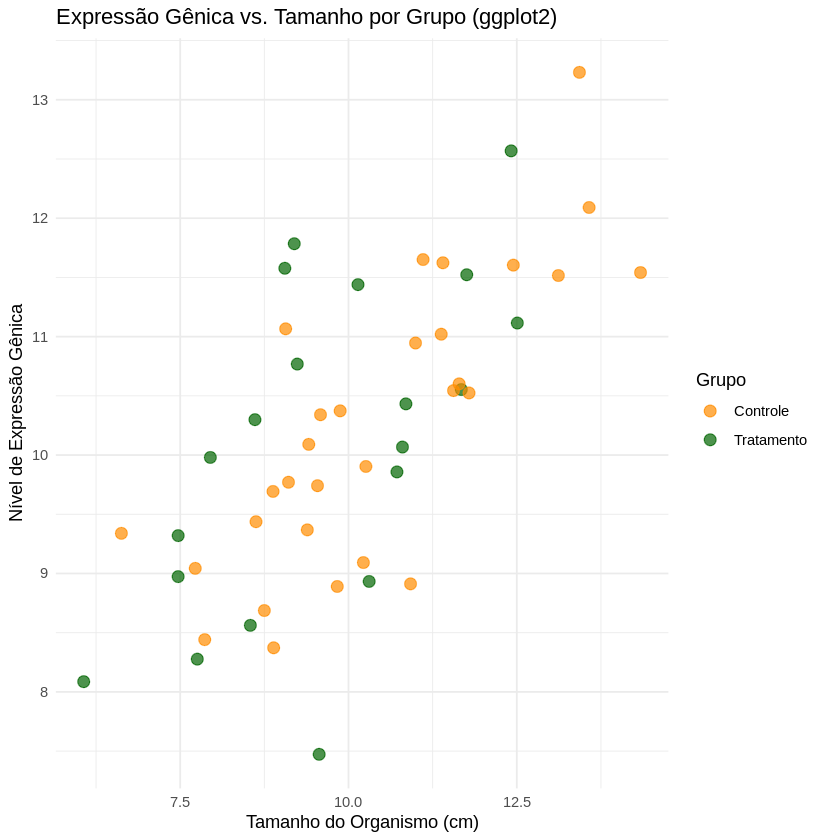

In [22]:
# Plot de dispersão com ggplot2
ggplot(data = data_for_ggplot, aes(x = Tamanho, y = Expressao, color = Grupo)) +
  geom_point(alpha = 0.7, size = 3) + # geom_point para pontos de dispersão
  labs(
    title = "Expressão Gênica vs. Tamanho por Grupo (ggplot2)",
    x = "Tamanho do Organismo (cm)",
    y = "Nível de Expressão Gênica"
  ) +
  theme_minimal() + # Um tema de gráfico minimalista
  scale_color_manual(values = c("Tratamento" = "darkgreen", "Controle" = "darkorange"))

# 3. Outros Tipos de Gráficos com `ggplot2` (Exemplo: Boxplot)
# `ggplot2` é versátil e pode criar muitos outros tipos de gráficos.
# Vamos ver um boxplot para comparar a expressão gênica entre os grupos.

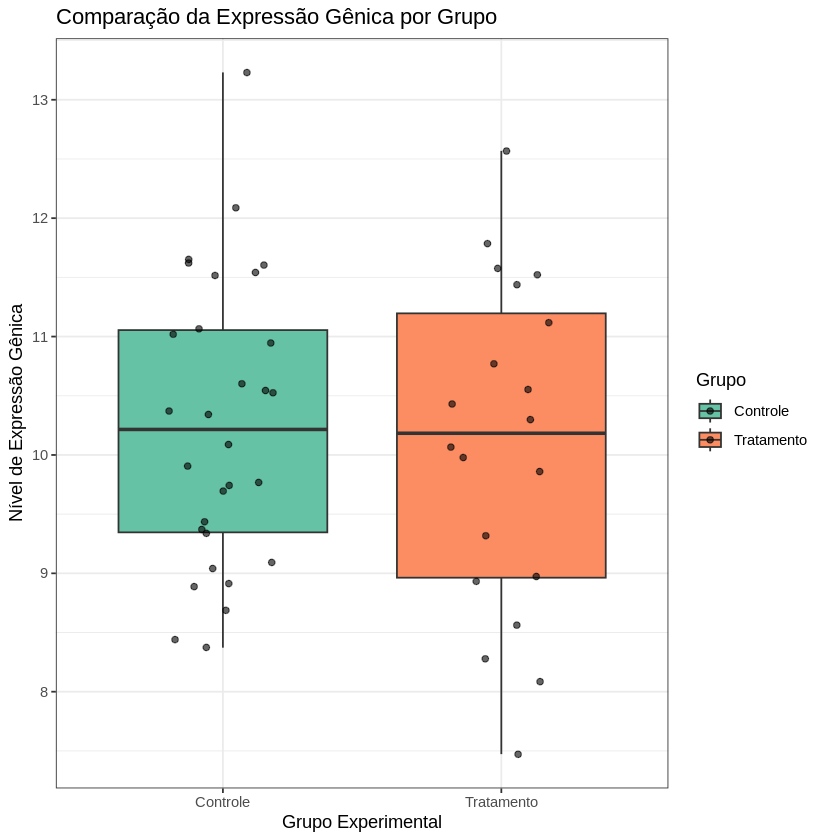

In [23]:
ggplot(data = data_for_ggplot, aes(x = Grupo, y = Expressao, fill = Grupo)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.6) + # Adiciona os pontos individuais
  labs(
    title = "Comparação da Expressão Gênica por Grupo",
    x = "Grupo Experimental",
    y = "Nível de Expressão Gênica"
  ) +
  theme_bw() + # Outro tema popular
  scale_fill_brewer(palette = "Set2") # Cores usando paleta predefinida

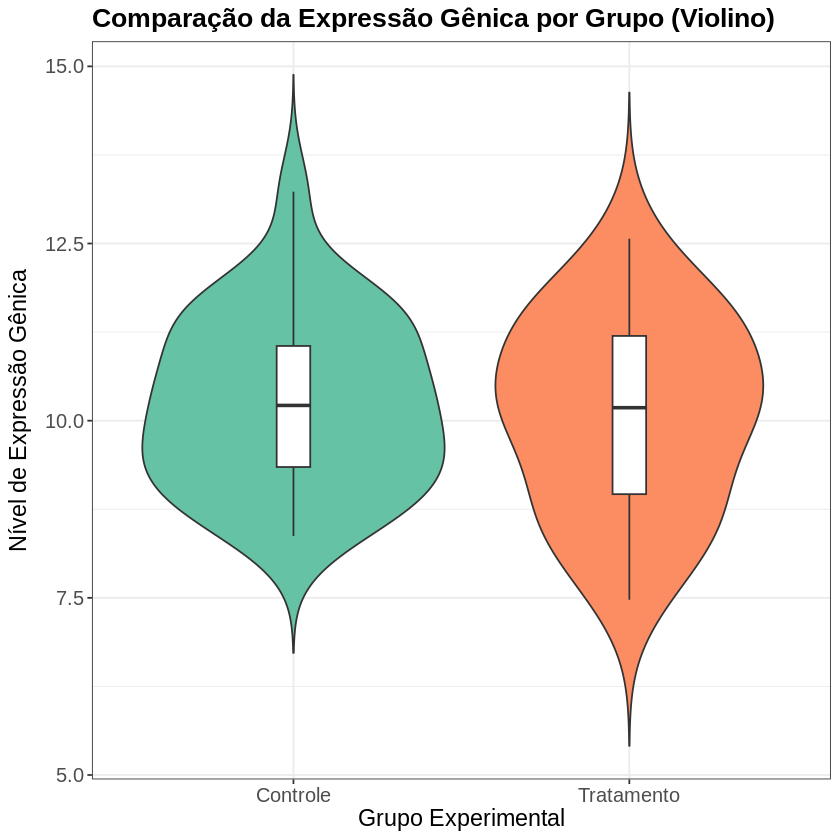

In [24]:
# Gráfico de Violino da Expressão Gênica por Grupo
ggplot(data = data_for_ggplot, aes(x = Grupo, y = Expressao, fill = Grupo)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.1, fill = "white") + # Adiciona um boxplot dentro do violino
  labs(
    title = "Comparação da Expressão Gênica por Grupo (Violino)",
    x = "Grupo Experimental",
    y = "Nível de Expressão Gênica"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "none" # Remove a legenda para este gráfico
  ) +
  scale_fill_brewer(palette = "Set2")

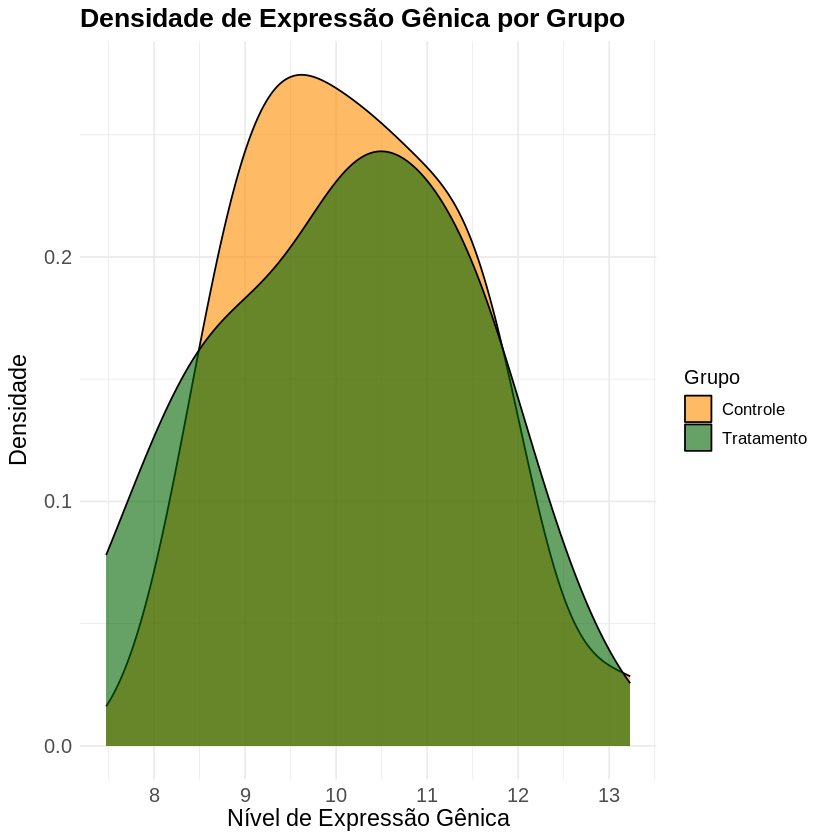

In [25]:
ggplot(data = data_for_ggplot, aes(x = Expressao, fill = Grupo)) +
  geom_density(alpha = 0.6) +
  labs(
    title = "Densidade de Expressão Gênica por Grupo",
    x = "Nível de Expressão Gênica",
    y = "Densidade"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10)
  ) +
  scale_fill_manual(values = c("Tratamento" = "darkgreen", "Controle" = "darkorange"))

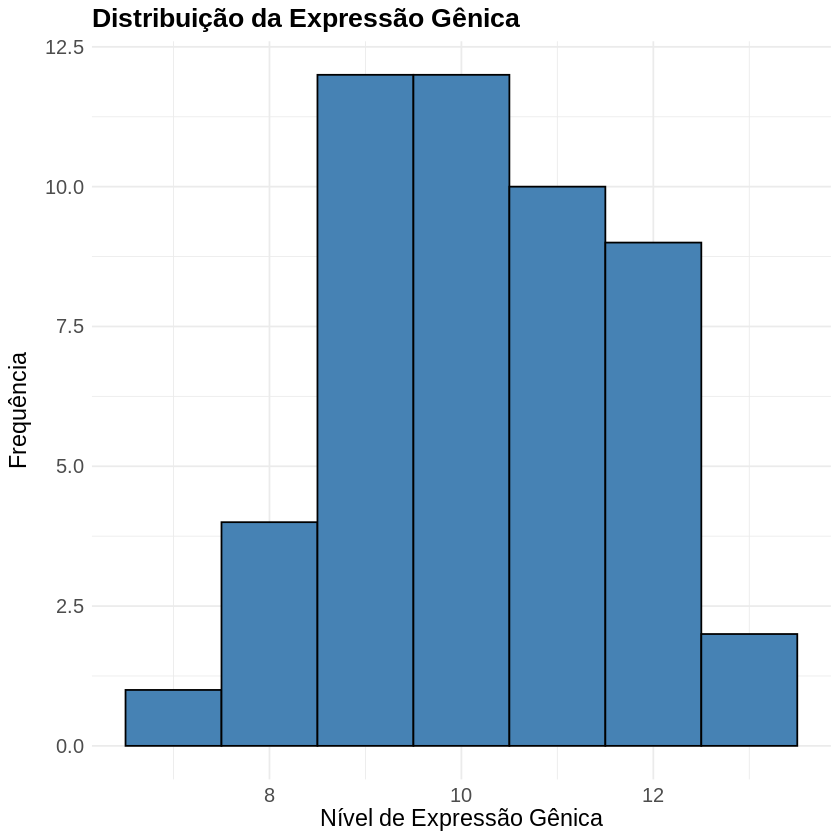

In [26]:
# Histograma da Expressão Gênica
ggplot(data = data_for_ggplot, aes(x = Expressao)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "black") +
  labs(
    title = "Distribuição da Expressão Gênica",
    x = "Nível de Expressão Gênica",
    y = "Frequência"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12)
  )

## Conclusão
Este notebook demonstrou como criar visualizações de dados usando tanto as funções de plotagem base do R quanto a biblioteca `ggplot2`. Para análises mais aprofundadas e personalizadas, `ggplot2` é geralmente a escolha preferida devido à sua flexibilidade e sintaxe expressiva.